<a href="https://colab.research.google.com/github/khush2705/ML_safety/blob/main/Exercise_04/MLSafety_Exercise_4.7(General%20test%20set).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/MLSafety"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import csv
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

TEST_CSV  = f"{BASE_PATH}/test/labels.csv"
TEST_IMG  = f"{BASE_PATH}/test/rgb-front"
MODEL_DIR = f"{BASE_PATH}/model_outputs"

LABELS = ['has_traffic_light', 'has_pedestrian', 'has_vehicle']
BATCH_SIZE = 32

Device: cuda


In [ ]:
class DrivingDataset(Dataset):
    def __init__(self, csv_path, img_dir, label_col, transform=None):
        self.transform = transform
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def load_model(label_col):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 1)
    path = os.path.join(MODEL_DIR, f"best_{label_col}.pth")
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def get_predictions(model, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            preds = (torch.sigmoid(out).squeeze() > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
    return np.array(all_labels), np.array(all_preds)

print("✅ Functions defined.")


✅ Functions defined.



  Evaluating: has_traffic_light
  Accuracy:  0.9467
  Precision: 0.9433
  Recall:    0.9849
  F1-score:  0.9637

              precision    recall  f1-score   support

      Absent       0.96      0.85      0.90      1016
     Present       0.94      0.98      0.96      2584

    accuracy                           0.95      3600
   macro avg       0.95      0.92      0.93      3600
weighted avg       0.95      0.95      0.95      3600


  Evaluating: has_pedestrian
  Accuracy:  0.6239
  Precision: 0.2787
  Recall:    0.5779
  F1-score:  0.3760

              precision    recall  f1-score   support

      Absent       0.86      0.64      0.73      2894
     Present       0.28      0.58      0.38       706

    accuracy                           0.62      3600
   macro avg       0.57      0.61      0.55      3600
weighted avg       0.75      0.62      0.66      3600


  Evaluating: has_vehicle
  Accuracy:  0.8717
  Precision: 0.9586
  Recall:    0.8663
  F1-score:  0.9101

             

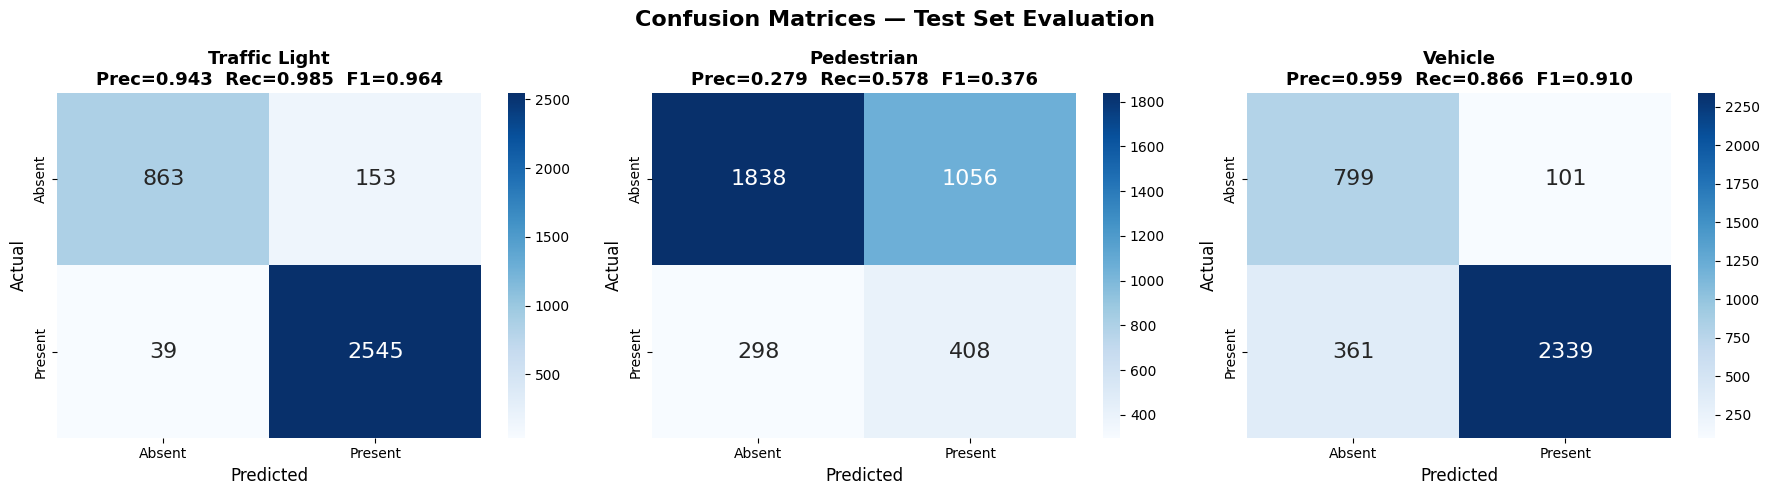

In [ ]:
results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, label_col in enumerate(LABELS):
    print(f"\n{'='*60}")
    print(f"  Evaluating: {label_col}")
    print(f"{'='*60}")

    model = load_model(label_col)
    test_ds = DrivingDataset(TEST_CSV, TEST_IMG, label_col, test_transform)
    nw = 2 if torch.cuda.is_available() else 0
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=nw, pin_memory=torch.cuda.is_available())

    y_true, y_pred = get_predictions(model, test_loader)

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Absent', 'Present'])}")

    results.append({
        'label': label_col, 'accuracy': acc,
        'precision': prec, 'recall': rec, 'f1': f1
    })

    # Confusion matrix plot
    cm = confusion_matrix(y_true, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Absent', 'Present'],
                yticklabels=['Absent', 'Present'],
                annot_kws={"size": 16})
    title = label_col.replace('has_', '').replace('_', ' ').title()
    ax.set_title(f'{title}\nPrec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)

plt.suptitle('Confusion Matrices — Test Set Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

